In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.pipeline import FunctionTransformer

import seaborn as sns
import warnings
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.components import connected_components

warnings.filterwarnings("ignore")

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.decomposition import PCA


from sklearn.preprocessing import PowerTransformer

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

from sklearn.ensemble import IsolationForest

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score, recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    roc_auc_score,
    classification_report,
)

In [2]:
from ucimlrepo import fetch_ucirepo

polish_companies_bankruptcy = fetch_ucirepo(id=365)

X = polish_companies_bankruptcy.data.features
y = polish_companies_bankruptcy.data.targets

### Zapoznanie z danymi

In [3]:
X["class"] = y
X.head()

,year,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,A56,A57,A58,A59,A60,A61,A62,A63,A64,class
0,1,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,...,0.121960,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0
1,1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,...,0.121300,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0
2,1,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,...,0.241140,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0
3,1,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,...,0.054015,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0
4,1,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,...,0.134850,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0


### Liczba firm w danych latach

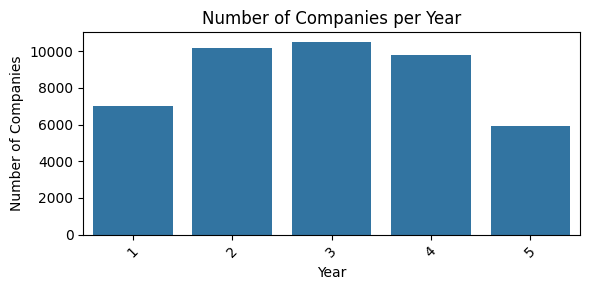

In [4]:
years = X["year"].unique()
counts = X["year"].value_counts().sort_index()

plt.figure(figsize=(6, 3))
sns.barplot(x=years, y=counts.values)
plt.title("Number of Companies per Year")
plt.xlabel("Year")
plt.ylabel("Number of Companies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Proporcje klas

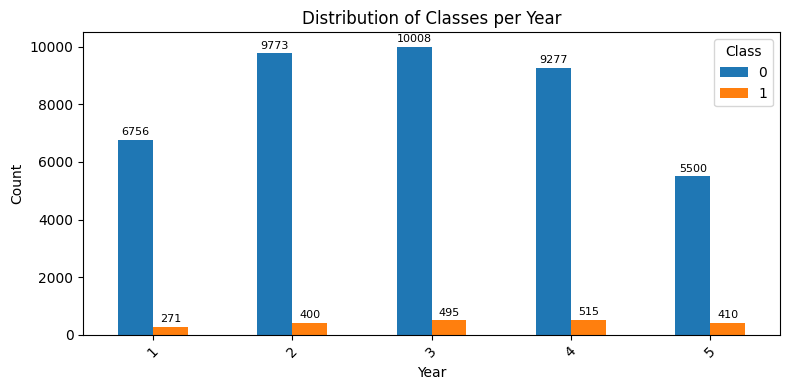

In [5]:
class_counts_by_year = X.groupby("year")["class"].value_counts().unstack(fill_value=0)
ax = class_counts_by_year.plot(
    kind="bar",
    stacked=False,
    figsize=(8, 4),
    color=["tab:blue", "tab:orange"],
)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=2, fontsize=8)

plt.title("Distribution of Classes per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Class", loc="upper right")
plt.tight_layout()
plt.show()

### Liczba brakujących danych w danych latach

In [6]:
missing_by_year = X.groupby("year").apply(lambda df: df.isna().sum().sum())
missing_by_year = missing_by_year.astype(int).sort_index()

print("Liczba braków danych w zależności od roku:")
print(missing_by_year.to_string())

Liczba braków danych w zależności od roku:
year
1     5835
2    12157
3     9888
4     8776
5     4666


### Wybieramy rok o ID = 4

In [7]:
mask_2010 = X["year"] == 4

X = X[mask_2010].drop(columns=["year"])
y = y[mask_2010]

In [8]:
pd.set_option("display.max_rows", 500)
X.describe().T

,count,mean,std,min,25%,50%,75%,max
A1,9791.0,0.043019,0.359321,-1.245800e+01,0.001321,0.041364,0.111130,2.048200e+01
A2,9791.0,0.596404,4.587122,0.000000e+00,0.263145,0.467740,0.689255,4.469100e+02
A3,9791.0,0.130959,4.559074,-4.459100e+02,0.020377,0.199290,0.410670,2.276900e+01
A4,9749.0,8.136600,290.647281,-4.531900e-02,1.047000,1.591800,2.880400,2.714600e+04
A5,9771.0,64.255566,14732.269541,-3.790000e+05,-51.217000,-0.055576,55.732000,1.030000e+06
A6,9791.0,-0.059273,6.812754,-4.868200e+02,-0.000578,0.000000,0.065322,3.222000e+02
A7,9791.0,0.059446,0.533344,-1.245800e+01,0.003004,0.048820,0.126940,3.861800e+01
A8,9773.0,19.884016,698.697015,-1.848200e+00,0.428300,1.088700,2.691000,5.320900e+04
A9,9792.0,1.882296,17.674650,-3.237100e-02,1.006675,1.161300,1.970225,1.704800e+03
A10,9791.0,0.389040,4.590299,-4.459100e+02,0.294440,0.510450,0.714290,1.260200e+01


### Proporcje klas

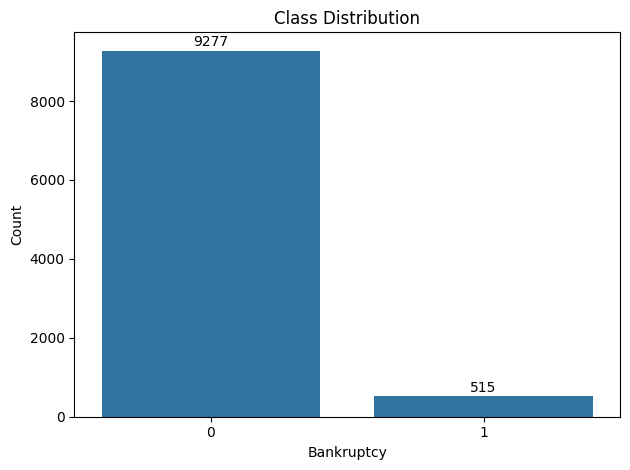

In [9]:
sns.countplot(data=y, x="class")
plt.title("Class Distribution")
plt.xlabel("Bankruptcy")
plt.ylabel("Count")
ax = plt.gca()

for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(
        f"{height}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 1),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()

### Procent brakow danych per feature

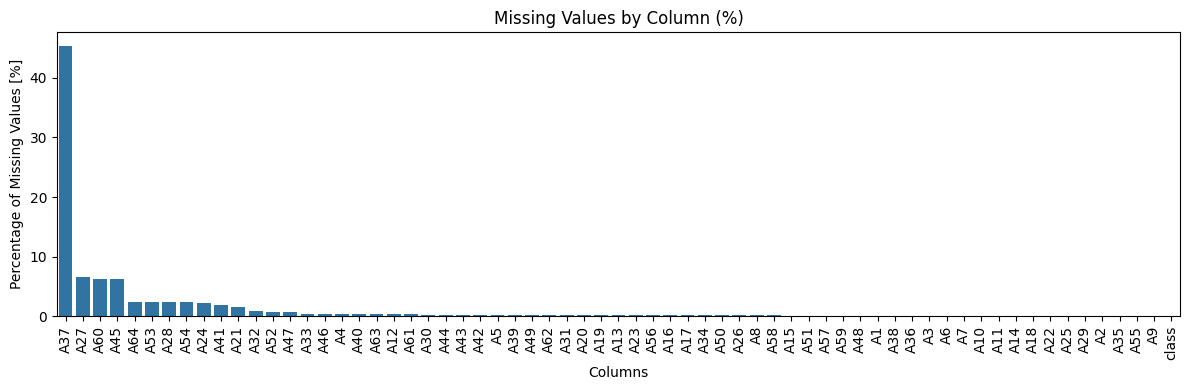

In [10]:
missing_values = X.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_values / len(X)) * 100

plt.figure(figsize=(12, 4))
ax = sns.barplot(x=missing_pct.index, y=missing_pct.values)
plt.xticks(rotation=90)
plt.title("Missing Values by Column (%)")
plt.xlabel("Columns")
plt.ylabel("Percentage of Missing Values [%]")
plt.tight_layout()
plt.show()

### Mapa braków danych

In [11]:
X = X.drop(columns=["A37"])

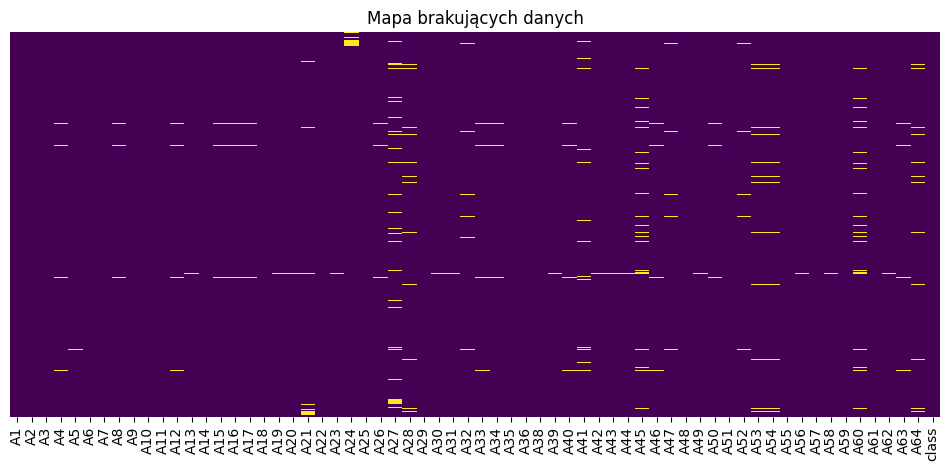

In [12]:
plt.figure(figsize=(12, 5))
sns.heatmap(X.isnull(), yticklabels=False, cbar=False, cmap="viridis")
plt.title("Mapa brakujących danych")
plt.show()

### Liczba brakow danych w rekordach z podzialem na klasy

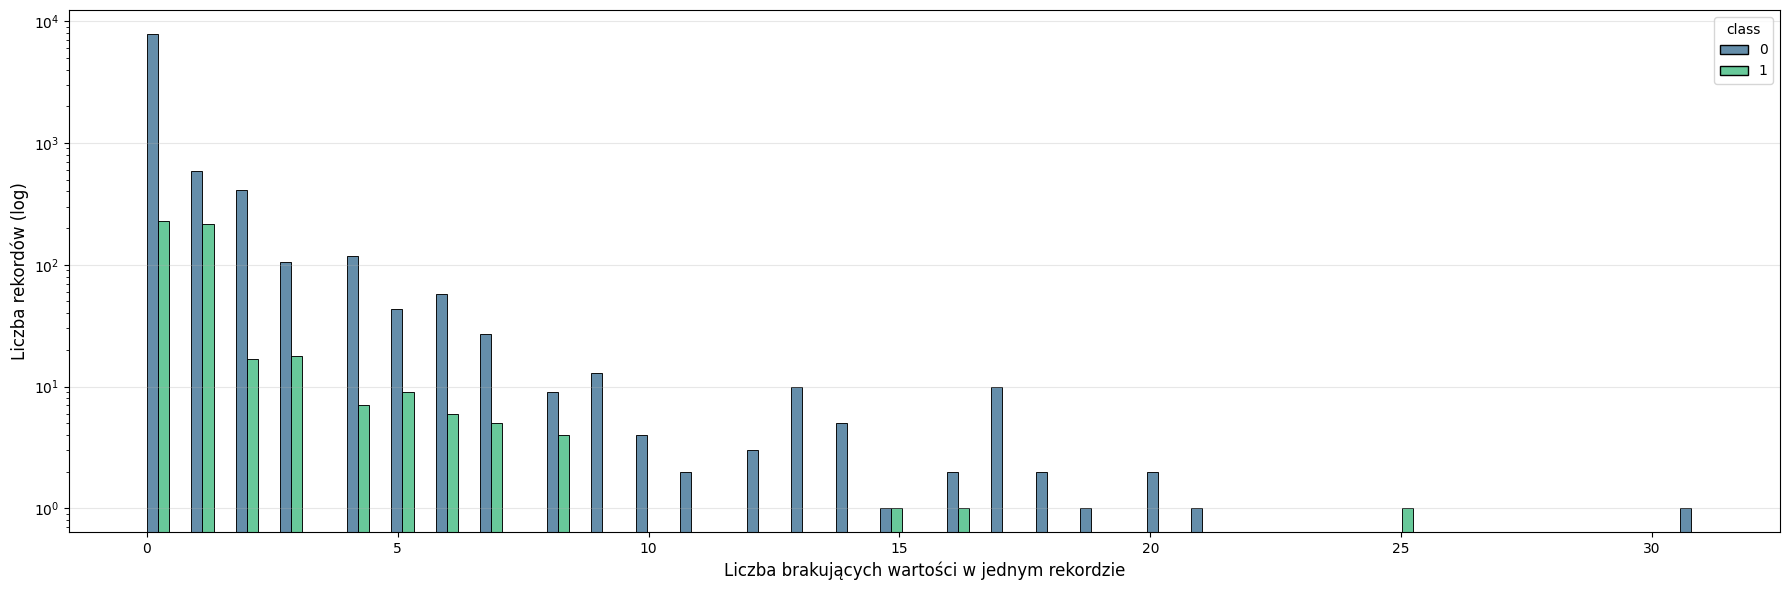

In [13]:
X["missing_count"] = X.drop(columns=["class"]).isnull().sum(axis=1)

plt.figure(figsize=(18, 6))

sns.histplot(
    data=X,
    x="missing_count",
    hue="class",
    bins=70,
    kde=False,
    palette="viridis",
    multiple="dodge",
)

plt.xlabel("Liczba brakujących wartości w jednym rekordzie", fontsize=12)
plt.ylabel("Liczba rekordów (log)", fontsize=12)

plt.yscale("log")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Dystrybucje cech

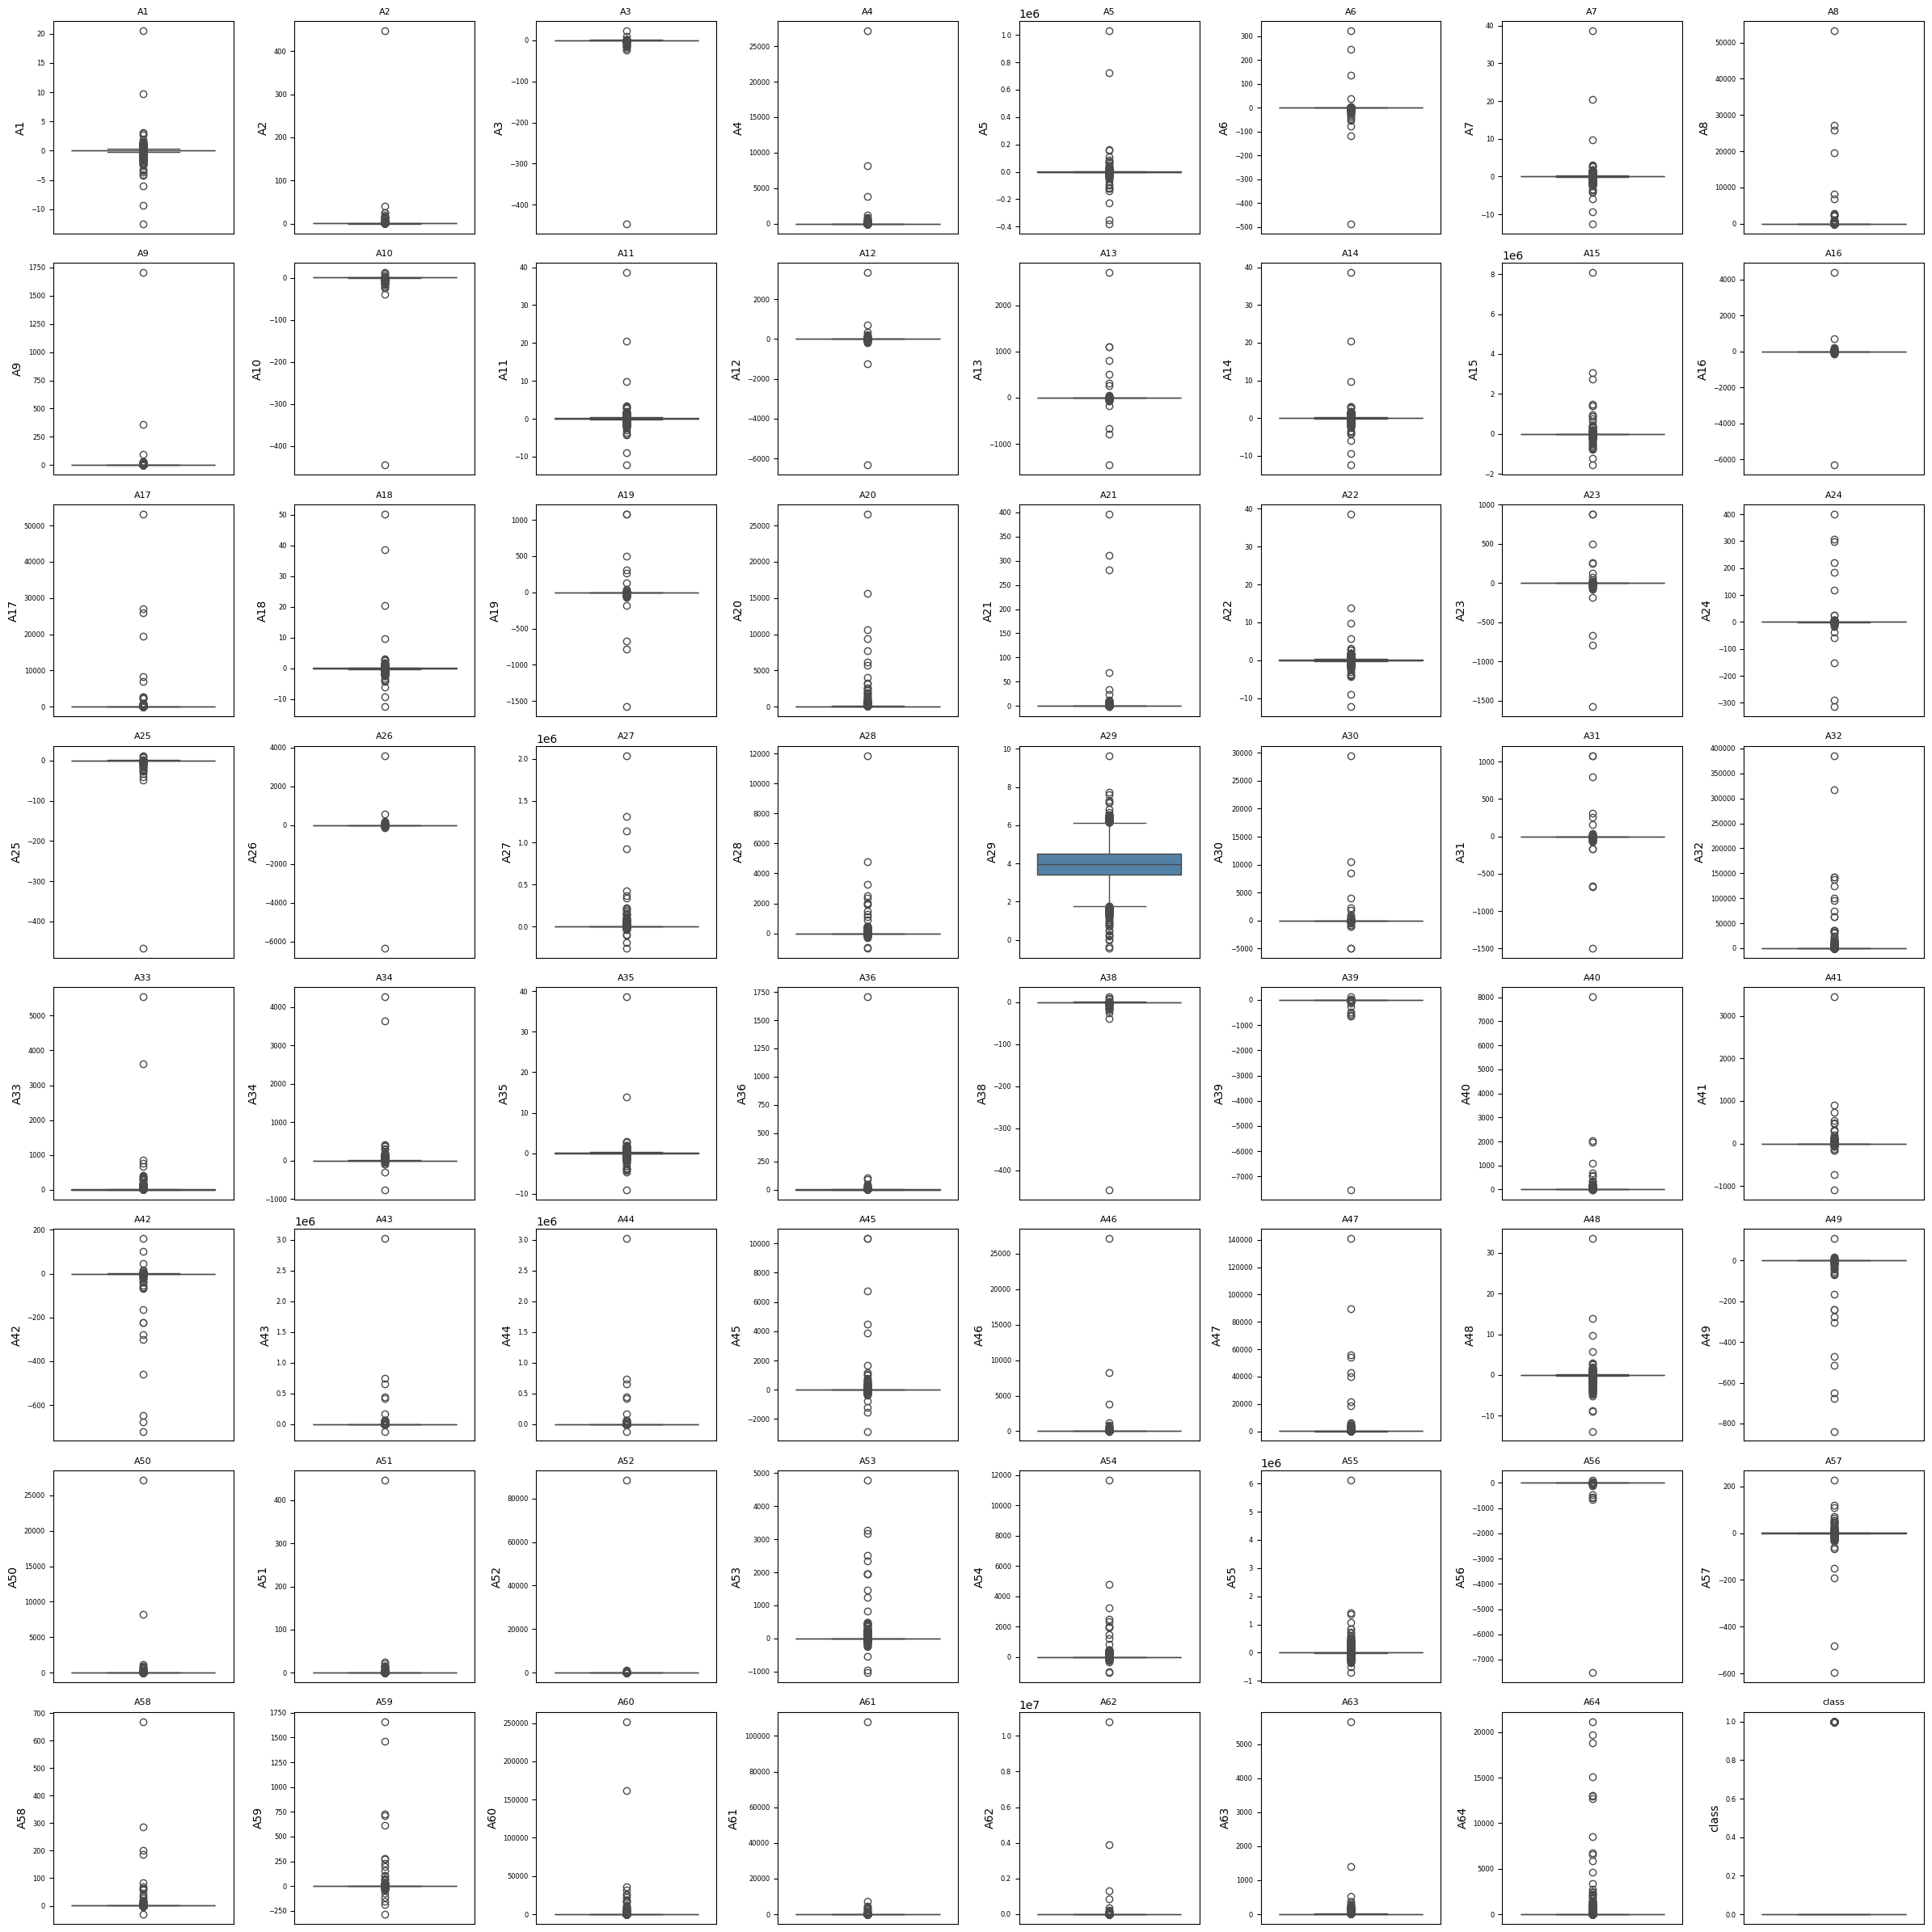

In [14]:
X = X.drop(columns=["missing_count"])
cols = X.columns
n_cols = 8
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(n_cols * 3, n_rows * 3))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=X[col], color="steelblue")
    plt.title(col, fontsize=8)
    plt.xticks([])
    plt.yticks(fontsize=6)

plt.tight_layout()
plt.show()

___

### train test split ze stratyfikacją po klasie

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X.drop(columns=["class"]),
    X["class"],
    test_size=0.2,
    stratify=X["class"],
    random_state=42,
)

### Porownanie proporcji klas w zbiorze treningowym i testowym

In [16]:
proportion_train = y_train.value_counts(normalize=True).sort_index()
proportion_test = y_test.value_counts(normalize=True).sort_index()

comparison = pd.concat(
    [proportion_train.rename("train"), proportion_test.rename("test")], axis=1
).fillna(0)


print("Porównanie proporcji klas")
print((comparison * 100).round(2))

Porównanie proporcji klas
       train   test
class              
0      94.74  94.74
1       5.26   5.26


___

In [17]:
class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, k=1.5):
        self.k = k

    def fit(self, X, y=None):
        X = np.array(X)
        Q1 = np.nanpercentile(X, 25, axis=0)
        Q3 = np.nanpercentile(X, 75, axis=0)
        IQR = Q3 - Q1
        self.lower_ = Q1 - self.k * IQR
        self.upper_ = Q3 + self.k * IQR
        return self

    def transform(self, X, y=None):
        X = np.array(X, dtype=float)
        return np.clip(X, self.lower_, self.upper_)


class PassthroughTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.n_features_in_ = np.array(X).shape[1]
        return self

    def transform(self, X, y=None):
        return np.array(X, dtype=float)

In [18]:
def build_outlier_profile_by_class(X_df, y_ser, k=1.5):
    Xw = X_df.reset_index(drop=True)
    yw = pd.Series(y_ser).astype(int).reset_index(drop=True)

    q1 = Xw.quantile(0.25)
    q3 = Xw.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr

    outlier_mask = ((Xw.lt(lower)) | (Xw.gt(upper))) & Xw.notna()
    outlier_count = outlier_mask.sum(axis=1)

    outlier_df = pd.DataFrame(
        {
            "class": yw,
            "class_label": yw.astype(str),
            "outlier_count": outlier_count,
        }
    )
    outlier_df["has_outlier"] = (outlier_df["outlier_count"] > 0).astype(int)

    summary = (
        outlier_df.groupby("class", as_index=False)
        .agg(
            n_samples=("class", "size"),
            outlier_rows=("has_outlier", "sum"),
            avg_outliers_per_row=("outlier_count", "mean"),
            median_outliers_per_row=("outlier_count", "median"),
        )
        .sort_values("class")
    )
    summary["outlier_rows_pct"] = 100 * summary["outlier_rows"] / summary["n_samples"]
    return outlier_df, summary


outlier_df, summary = build_outlier_profile_by_class(X_train, y_train, k=1.5)

### Liczba outlierow w zbiorze

In [19]:
summary.round(3)

,class,n_samples,outlier_rows,avg_outliers_per_row,median_outliers_per_row,outlier_rows_pct
0,0,7421,6637,6.721,4.0,89.435
1,1,412,381,9.971,6.0,92.476


In [20]:
IMPUTERS = {
    "mean": SimpleImputer(strategy="mean"),
    "median": SimpleImputer(strategy="median"),
    "knn": KNNImputer(n_neighbors=5),
}

OUTLIERS = {
    "none": PassthroughTransformer(),
    "IQR_clip": IQRClipper(k=1.5),
    "power_transform": PowerTransformer(method="yeo-johnson"),
}

SCALERS = {
    "none": PassthroughTransformer(),
    "standard": StandardScaler(),
    "minmax": MinMaxScaler(),
    "robust": RobustScaler(),
}

MODELS = {
    "logistic_regression": LogisticRegression(random_state=42),
    "decision_tree": DecisionTreeClassifier(random_state=42),
}

In [21]:
missing_counts = X_train.isnull().sum()
top_k = 6
top_k_features = missing_counts.sort_values(ascending=False).head(top_k).index.tolist()
print(f"Top {top_k} features with most missing values: {top_k_features}")

Top 6 features with most missing values: ['A27', 'A60', 'A45', 'A64', 'A54', 'A53']


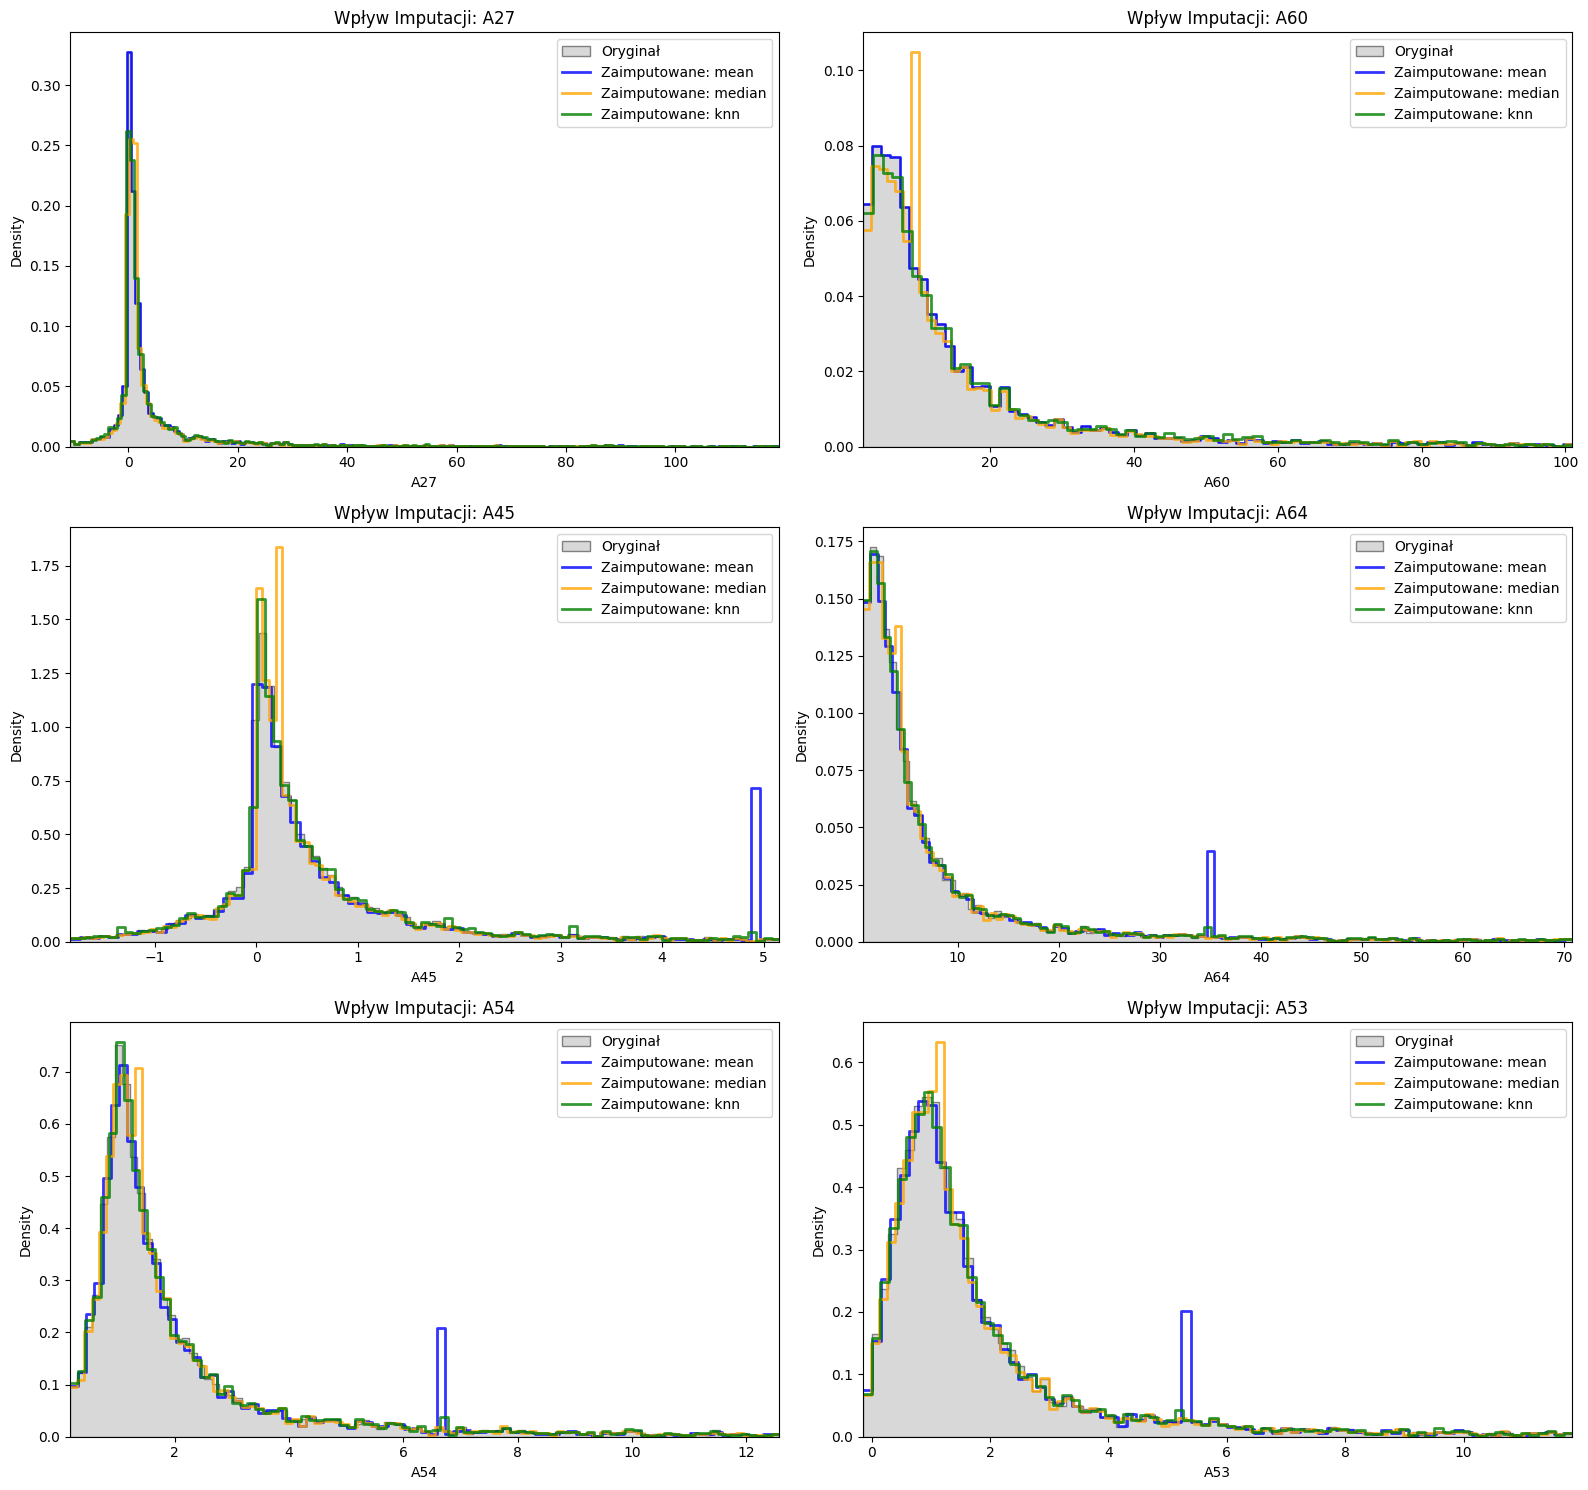

In [22]:
X_working = X_train[top_k_features].copy()

imputed_dfs = {}

for strategy in ["mean", "median"]:
    imputer = SimpleImputer(strategy=strategy)
    imputed_array = imputer.fit_transform(X_working)
    imputed_dfs[strategy] = pd.DataFrame(
        imputed_array, columns=top_k_features, index=X_working.index
    )


knn_pipeline = Pipeline(
    [("scaler", StandardScaler()), ("imputer", KNNImputer(n_neighbors=5))]
)

knn_imputed_scaled = knn_pipeline.fit_transform(X_working)
knn_imputed_raw = knn_pipeline.named_steps["scaler"].inverse_transform(
    knn_imputed_scaled
)

imputed_dfs["knn"] = pd.DataFrame(
    knn_imputed_raw, columns=top_k_features, index=X_working.index
)
colors = {"mean": "blue", "median": "orange", "knn": "green"}

n_cols = 2
n_rows = (len(top_k_features) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()

for i, feature in enumerate(top_k_features):
    ax = axes[i]
    lower, upper = X_working[feature].quantile([0.05, 0.95])

    if lower == upper:
        lower = X_working[feature].min()
        upper = X_working[feature].max()

    sns.histplot(
        X_working[feature],
        ax=ax,
        label="Oryginał",
        color="gray",
        alpha=0.3,
        element="step",
        stat="density",
        binrange=(lower, upper),
    )

    for method_name, color in colors.items():
        if method_name in imputed_dfs:
            imputed_series = imputed_dfs[method_name][feature]

            sns.histplot(
                imputed_series,
                ax=ax,
                label=f"Zaimputowane: {method_name}",
                element="step",
                fill=False,
                stat="density",
                color=color,
                binrange=(lower, upper),
                linewidth=2,
                alpha=0.8,
            )

    ax.set_title(f"Wpływ Imputacji: {feature}")
    ax.set_xlim(lower, upper)
    ax.legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

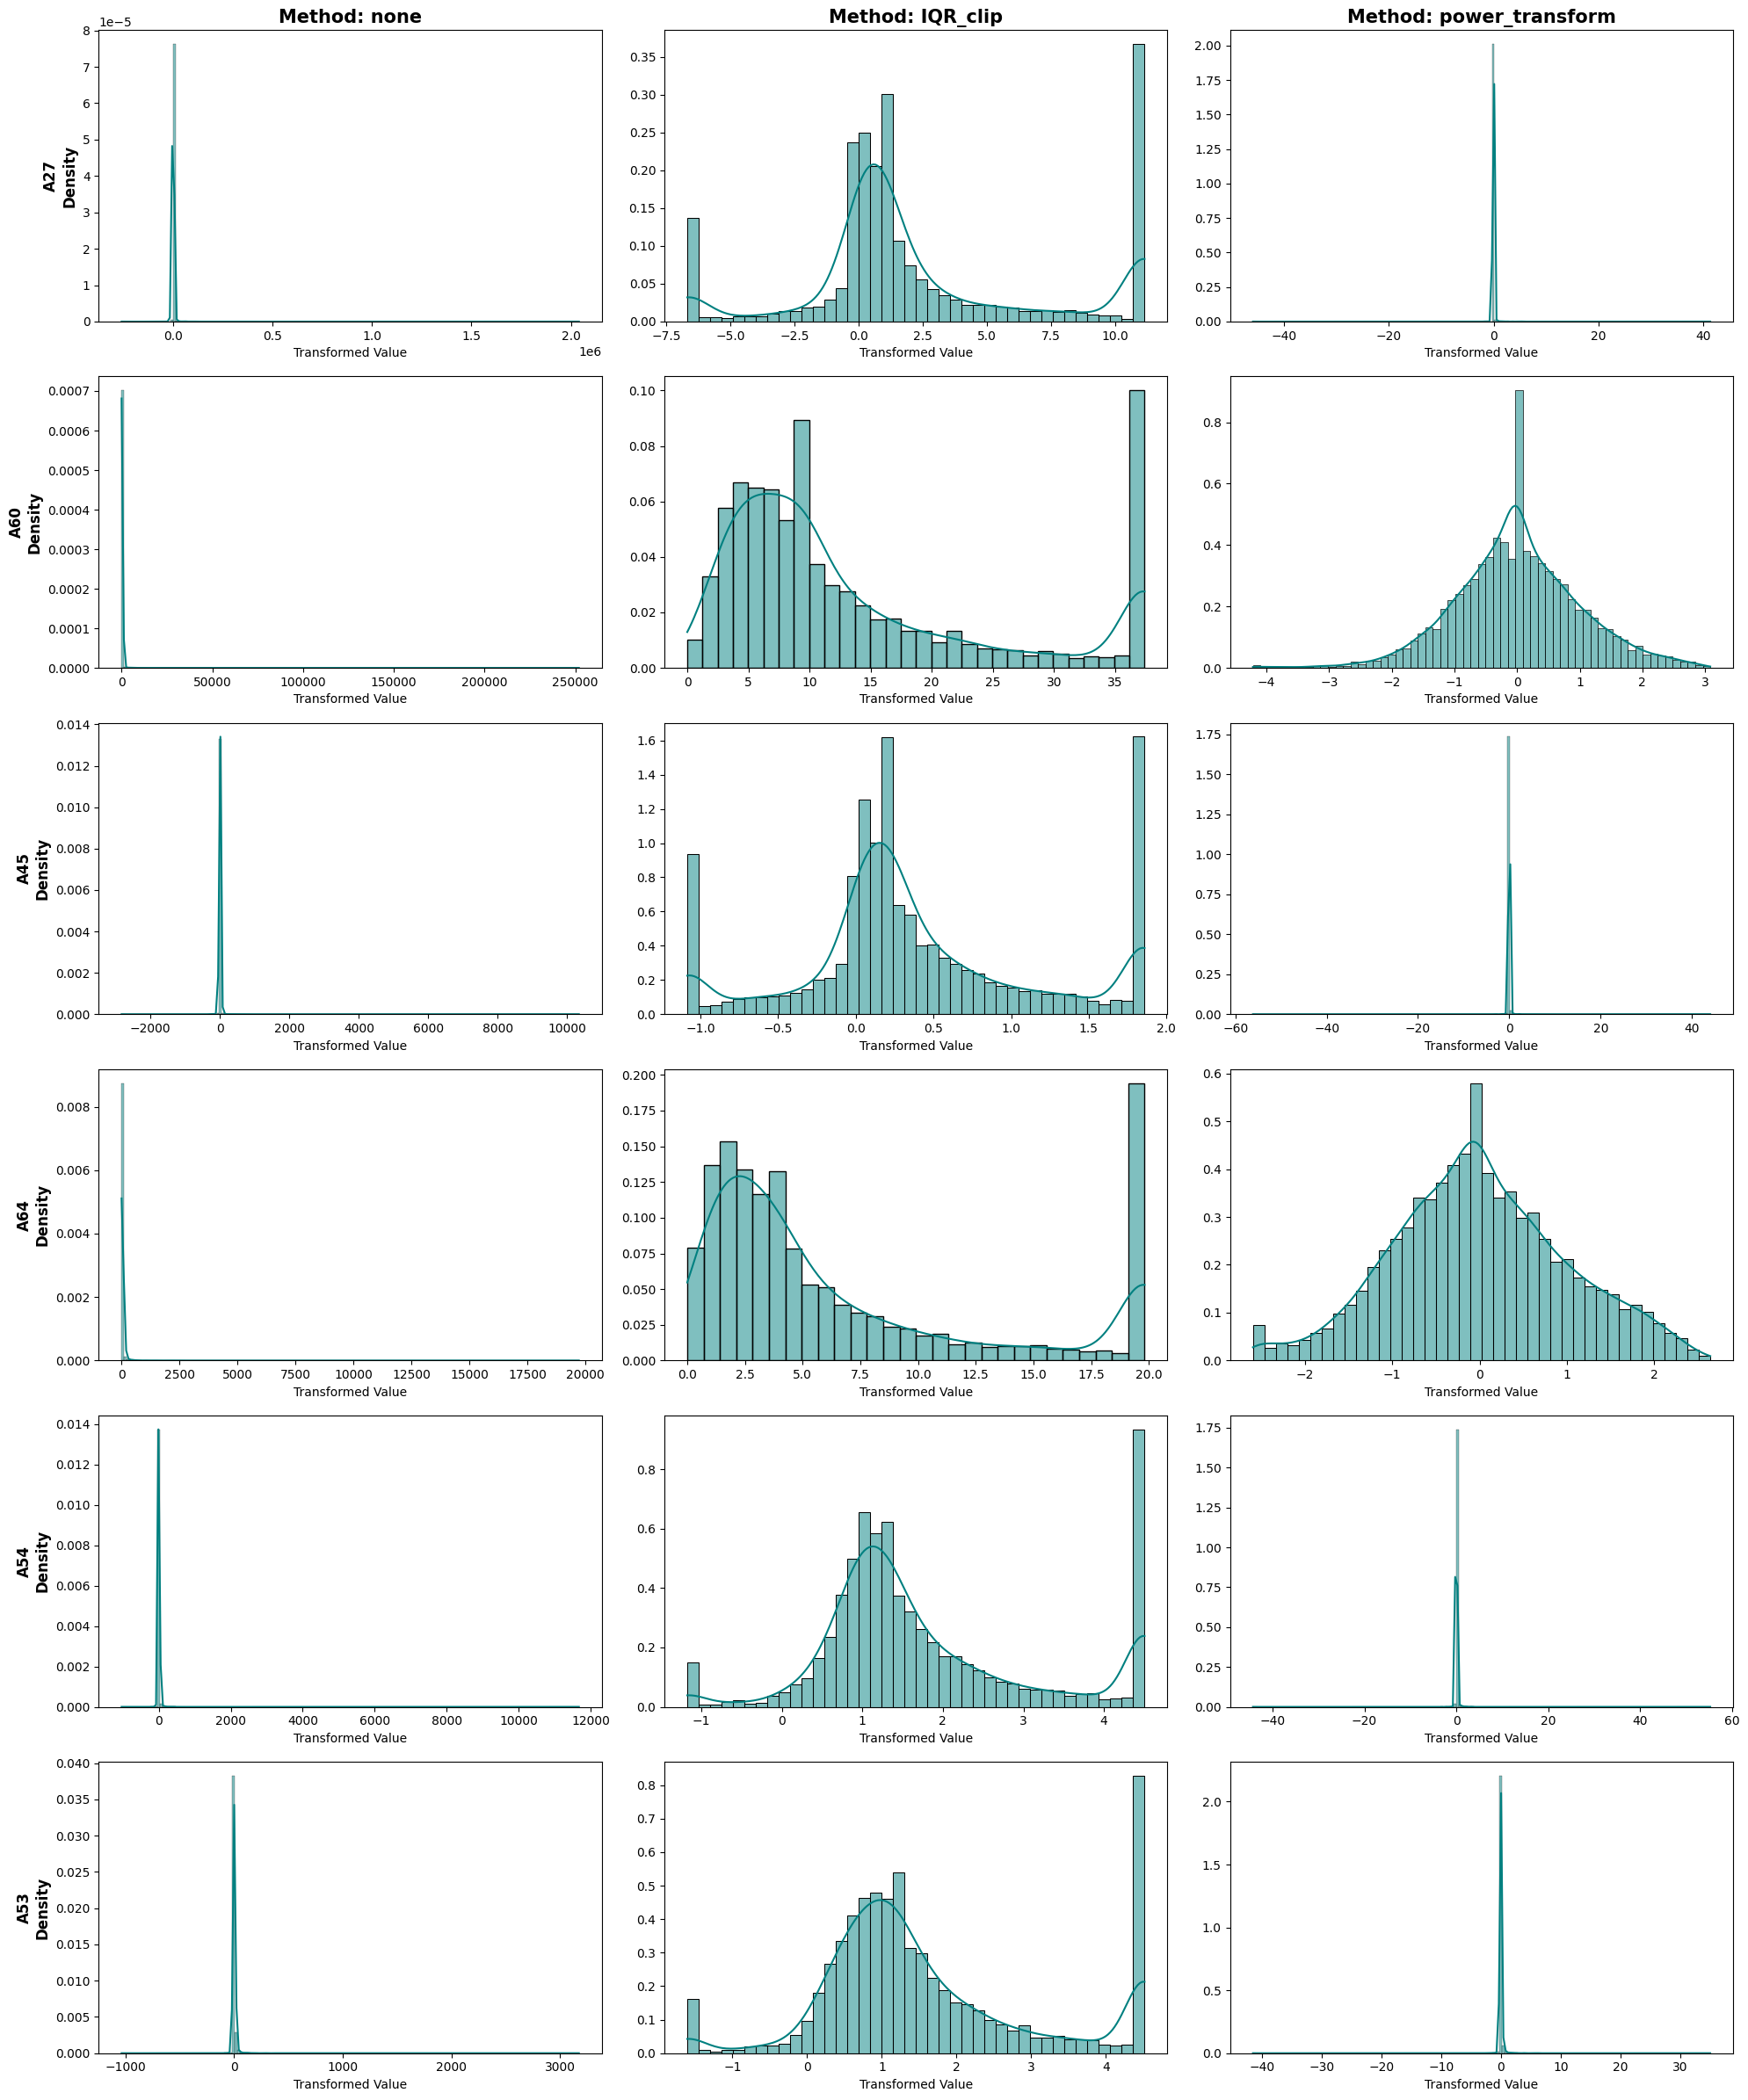

In [23]:
base_imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    base_imputer.fit_transform(X_train[top_k_features]), columns=top_k_features
)

n_features = len(top_k_features)
n_methods = len(OUTLIERS)

fig, axes = plt.subplots(n_features, n_methods, figsize=(20, n_features * 4))

for row_idx, feature in enumerate(top_k_features):
    data_to_transform = X_imputed[[feature]].values

    for col_idx, (method_name, transformer) in enumerate(OUTLIERS.items()):
        ax = axes[row_idx, col_idx]

        transformed_data = transformer.fit_transform(data_to_transform).flatten()

        sns.histplot(transformed_data, kde=True, ax=ax, color="teal", stat="density")

        if row_idx == 0:
            ax.set_title(f"Method: {method_name}", fontsize=15, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(f"{feature}\nDensity", fontsize=12, fontweight="bold")
        else:
            ax.set_ylabel("")
        ax.set_xlabel("Transformed Value")


plt.tight_layout()
plt.show()

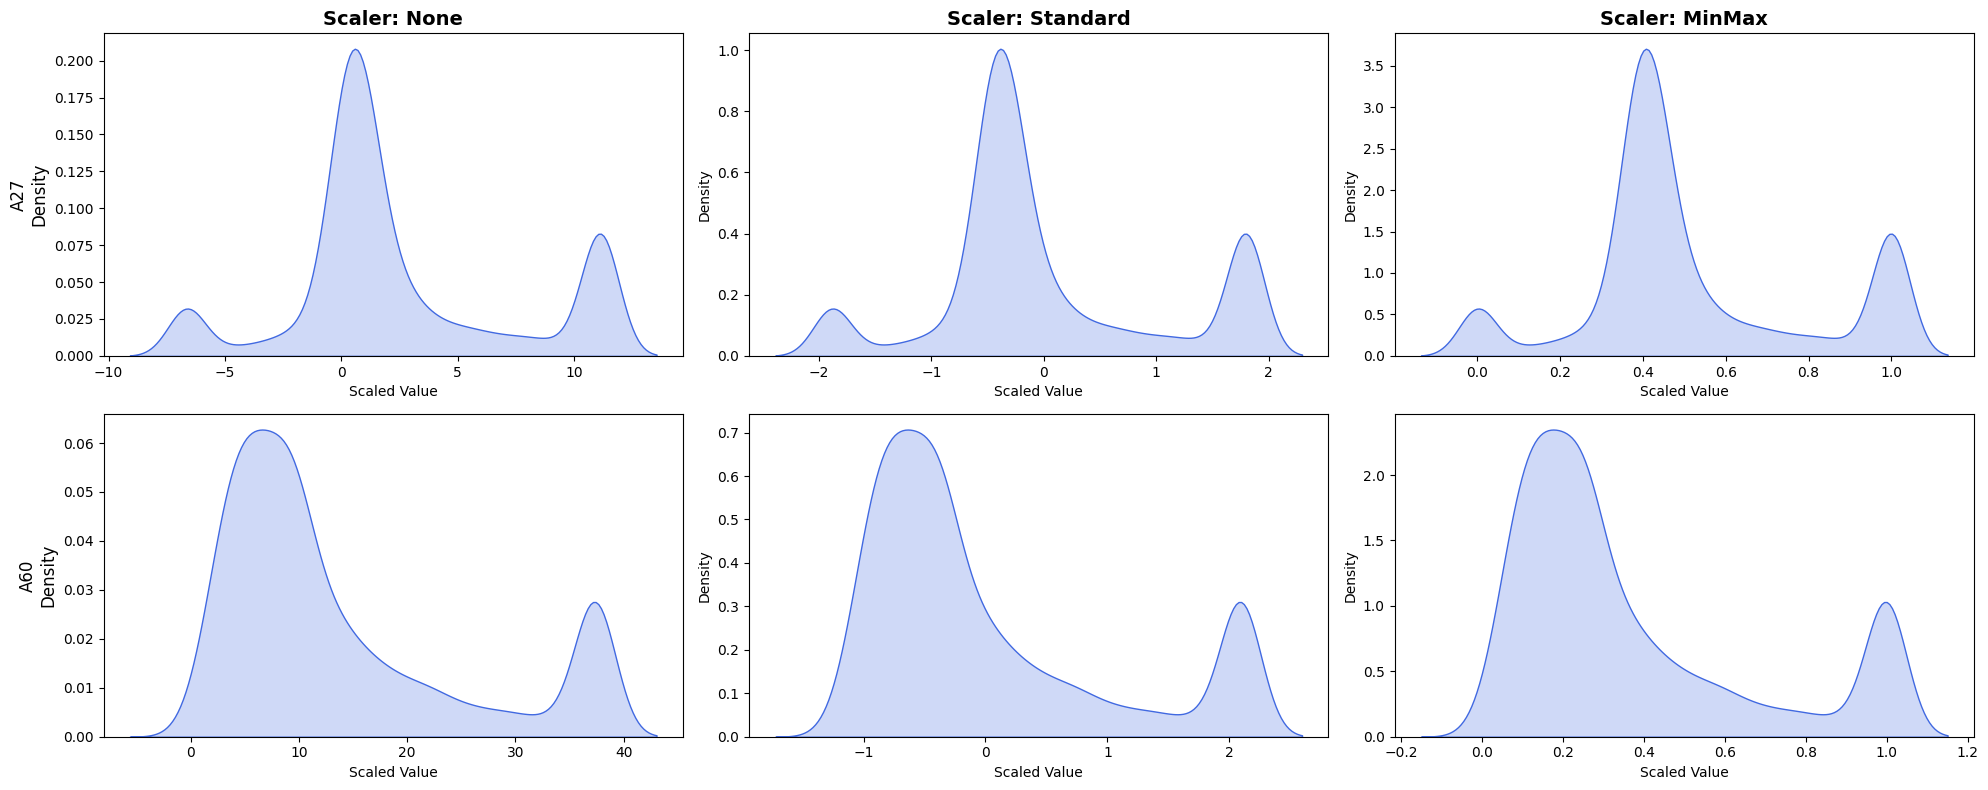

In [24]:
prep_imputer = SimpleImputer(strategy="median")
prep_transformer = IQRClipper(k=1.5)

featutes_to_plot = top_k_features[:2]

X_prepped = prep_imputer.fit_transform(X_train[featutes_to_plot])
X_prepped = prep_transformer.fit_transform(X_prepped)
X_prepped = pd.DataFrame(X_prepped, columns=featutes_to_plot)

SCALERS = {
    "None": PassthroughTransformer(),
    "Standard": StandardScaler(),
    "MinMax": MinMaxScaler(),
}

n_features = len(featutes_to_plot)
n_scalers = len(SCALERS)

fig, axes = plt.subplots(n_features, n_scalers, figsize=(20, n_features * 4))

for row_idx, feature in enumerate(featutes_to_plot):
    data_to_scale = X_prepped[[feature]].values

    for col_idx, (name, scaler) in enumerate(SCALERS.items()):
        ax = axes[row_idx, col_idx]
        scaled_data = scaler.fit_transform(data_to_scale).flatten()
        sns.kdeplot(scaled_data, ax=ax, fill=True, color="royalblue")

        if row_idx == 0:
            ax.set_title(f"Scaler: {name}", fontsize=14, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(f"{feature}\nDensity", fontsize=12)

        ax.set_xlabel("Scaled Value")

plt.tight_layout()
plt.show()

$$X_{scaled} = \frac{X - \text{Mediana}}{IQR}$$

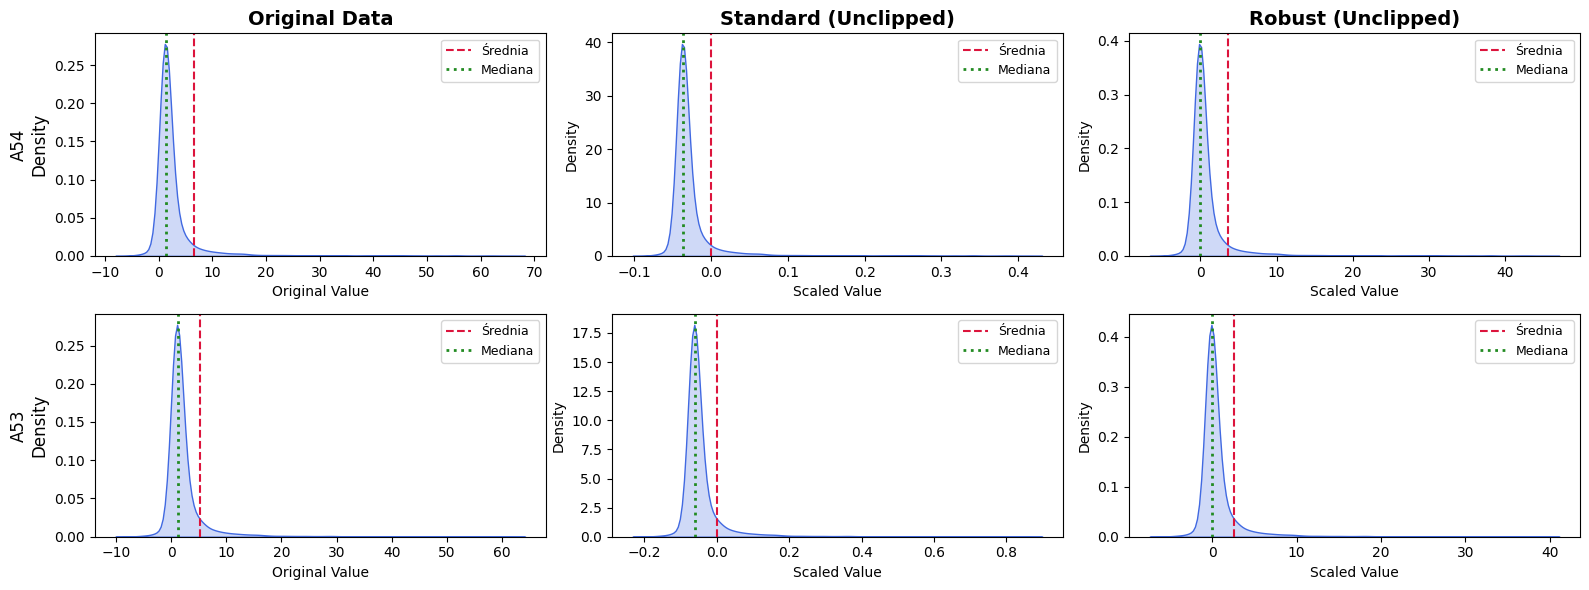

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, FunctionTransformer

# Twoje przygotowanie danych
prep_imputer = SimpleImputer(strategy="median")
X_imputed_raw = prep_imputer.fit_transform(X_train[top_k_features])
X_imputed = pd.DataFrame(X_imputed_raw, columns=top_k_features)

SCENARIOS = {
    "Original Data": (X_imputed, FunctionTransformer()),
    "Standard (Unclipped)": (X_imputed, StandardScaler()),
    "Robust (Unclipped)": (X_imputed, RobustScaler()),
}

features_to_plot = top_k_features[4:6]
n_features = len(features_to_plot)
n_scenarios = len(SCENARIOS)

fig, axes = plt.subplots(n_features, n_scenarios, figsize=(16, n_features * 3))

for row_idx, feature in enumerate(features_to_plot):
    for col_idx, (name, (data_df, scaler)) in enumerate(SCENARIOS.items()):
        ax = axes[row_idx, col_idx]

        data_to_scale = data_df[[feature]].values
        scaled_data = scaler.fit_transform(data_to_scale).flatten()

        mean_val = np.mean(scaled_data)
        median_val = np.median(scaled_data)

        lower_bound = np.percentile(scaled_data, 1)
        upper_bound = np.percentile(scaled_data, 99)
        mask = (scaled_data >= lower_bound) & (scaled_data <= upper_bound)
        data_to_plot = scaled_data[mask]

        sns.kdeplot(data_to_plot, ax=ax, fill=True, color="royalblue")

        ax.axvline(
            mean_val, color="crimson", linestyle="--", linewidth=1.5, label="Średnia"
        )
        ax.axvline(
            median_val, color="forestgreen", linestyle=":", linewidth=2, label="Mediana"
        )

        ax.legend(fontsize=9)

        if row_idx == 0:
            ax.set_title(f"{name}", fontsize=14, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(f"{feature}\nDensity", fontsize=12)

        ax.set_xlabel("Original Value" if name == "Original Data" else "Scaled Value")

plt.tight_layout()
plt.show()

* Dane są silnie prawoskośne. Ekstremalne wartości z długiego ogona sztucznie odciągają średnią w prawo, daleko od faktycznego środka danych
* Skupia się na ustawieniu *średniej* na zerze. Ponieważ średnia była zawyżona przez outliery, wycentrowanie jej na osi `0` zepchnęło właściwą masę naszych danych (szczyt) na wartości ujemne.
* Skupia się na ustawieniu *mediany* na zerze. Zielona linia trafia w `0` – skaler poprawnie wycentrował dane wokół ich naturalnego skupiska, ignorując wpływ outlierów.

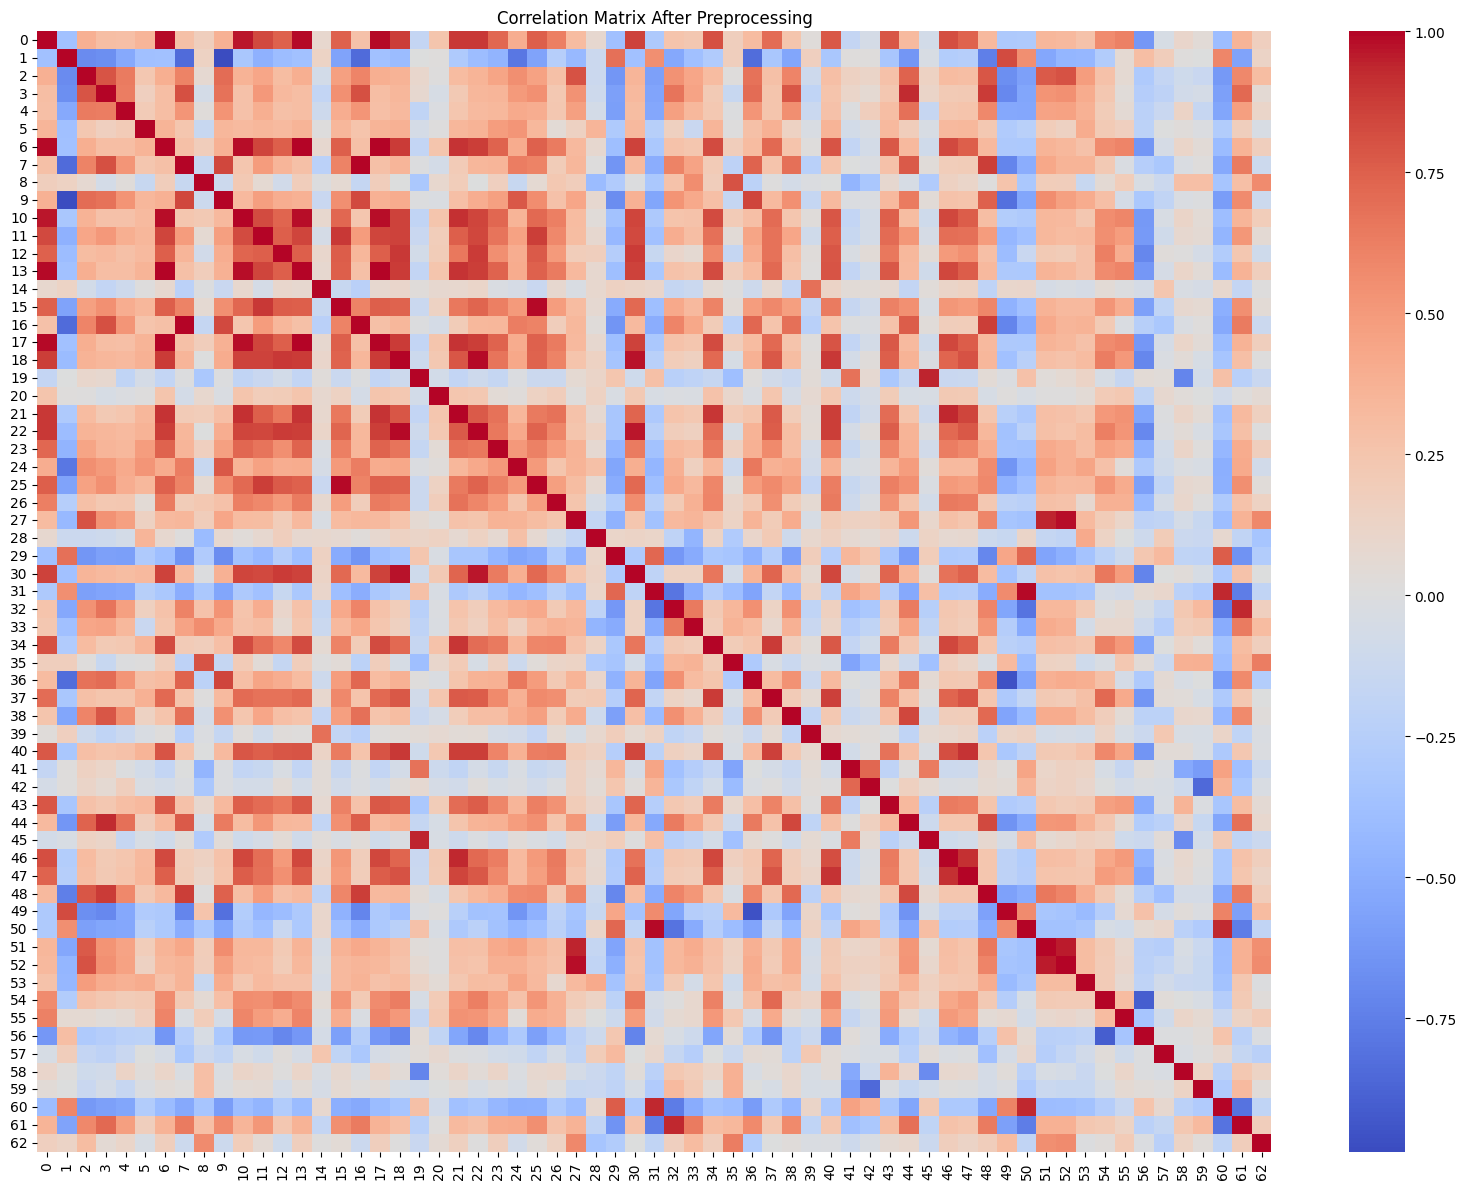

In [26]:
prep_imputer = SimpleImputer(strategy="median")
prep_transformer = IQRClipper(k=1.5)
scaler = StandardScaler()

pipe = Pipeline(
    [
        ("imputer", prep_imputer),
        ("outlier_treatment", prep_transformer),
        ("scaler", scaler),
    ]
)

X_prepped = pipe.fit_transform(X_train)
X_prepped = pd.DataFrame(X_prepped)
corr = X_prepped.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix After Preprocessing")
plt.tight_layout()
plt.show()

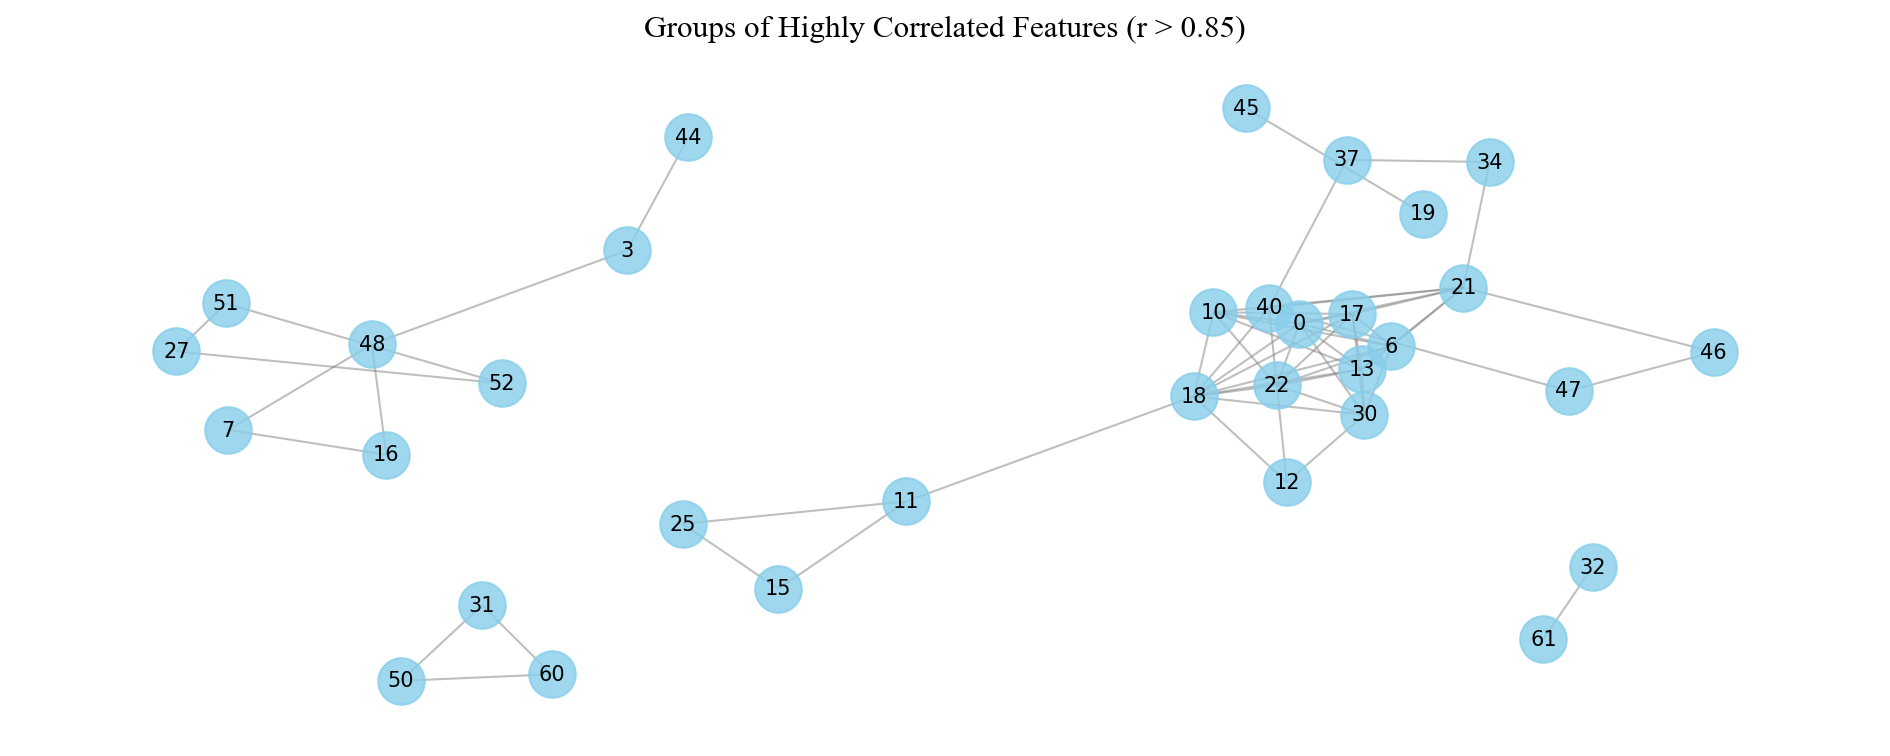

Detected Groups of Correlated Features:
Group 1: [0, 6, 10, 11, 12, 13, 15, 17, 18, 21, 22, 25, 30, 34, 37, 40, 46, 47]
Group 2: [3, 7, 16, 44, 48]
Group 3: [19, 45]
Group 4: [27, 51, 52]
Group 5: [31, 50, 60]
Group 6: [32, 61]


In [35]:
threshold = 0.85
links = corr.stack().reset_index()
links.columns = ["var1", "var2", "value"]
links_filtered = links[(links["value"] > threshold) & (links["var1"] != links["var2"])]

G = nx.from_pandas_edgelist(links_filtered, "var1", "var2")

plt.figure(figsize=(16, 6))
pos = nx.spring_layout(G, k=0.5)

nx.draw_networkx_nodes(G, pos, node_size=500, node_color="skyblue", alpha=0.8)
nx.draw_networkx_edges(G, pos, width=1.0, edge_color="gray", alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif")

plt.title(f"Groups of Highly Correlated Features (r > {threshold})", size=15)
plt.axis("off")
plt.show()

print("Detected Groups of Correlated Features:")
groups = list(connected_components(G))
for i, group in enumerate(groups, 1):
    print(f"Group {i}: {sorted(list(group))}")

Przykladowo grupa 1:
- X1	net profit / total assets
- X7	EBIT / total assets
- X11	(gross profit + extraordinary items + financial expenses) / total assets
- X13	(gross profit + depreciation) / sales
- X16	(gross profit + depreciation) / total liabilities

___

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X.drop(columns=["class"]),
    X["class"],
    test_size=0.2,
    stratify=X["class"],
    random_state=42,
)

### t-SNE

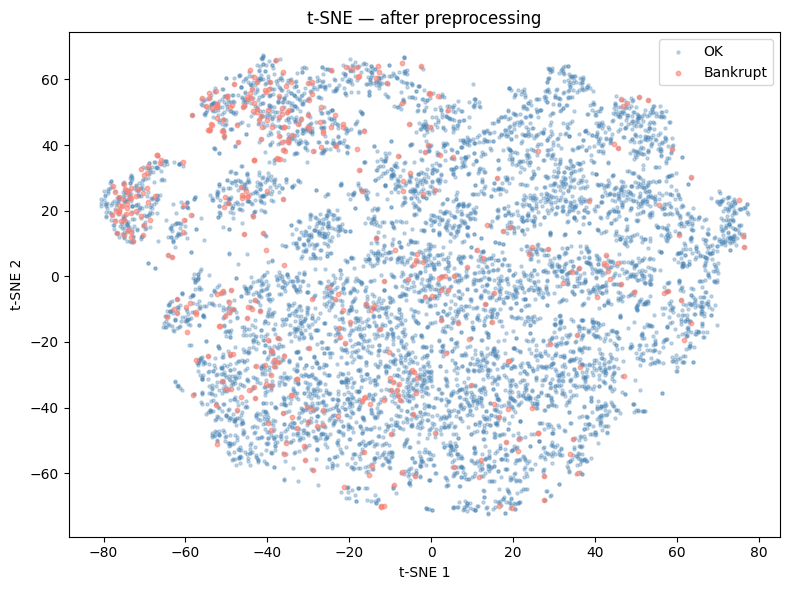

In [29]:
from sklearn.manifold import TSNE

pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("outlier_clipper", IQRClipper(k=1.5)),
        ("scaler", StandardScaler()),
    ]
)
pipe4 = pipeline
X_train_prepped = pipe4.fit_transform(X_train)
tsne = TSNE(n_components=2, random_state=42)

X_tsne = tsne.fit_transform(X_train_prepped)


plt.figure(figsize=(8, 6))
plt.scatter(
    X_tsne[y_train == 0, 0],
    X_tsne[y_train == 0, 1],
    c="steelblue",
    alpha=0.3,
    s=5,
    label="OK",
)
plt.scatter(
    X_tsne[y_train == 1, 0],
    X_tsne[y_train == 1, 1],
    c="salmon",
    alpha=0.6,
    s=10,
    label="Bankrupt",
)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE — after preprocessing")
plt.legend()
plt.tight_layout()
plt.show()

### PCA

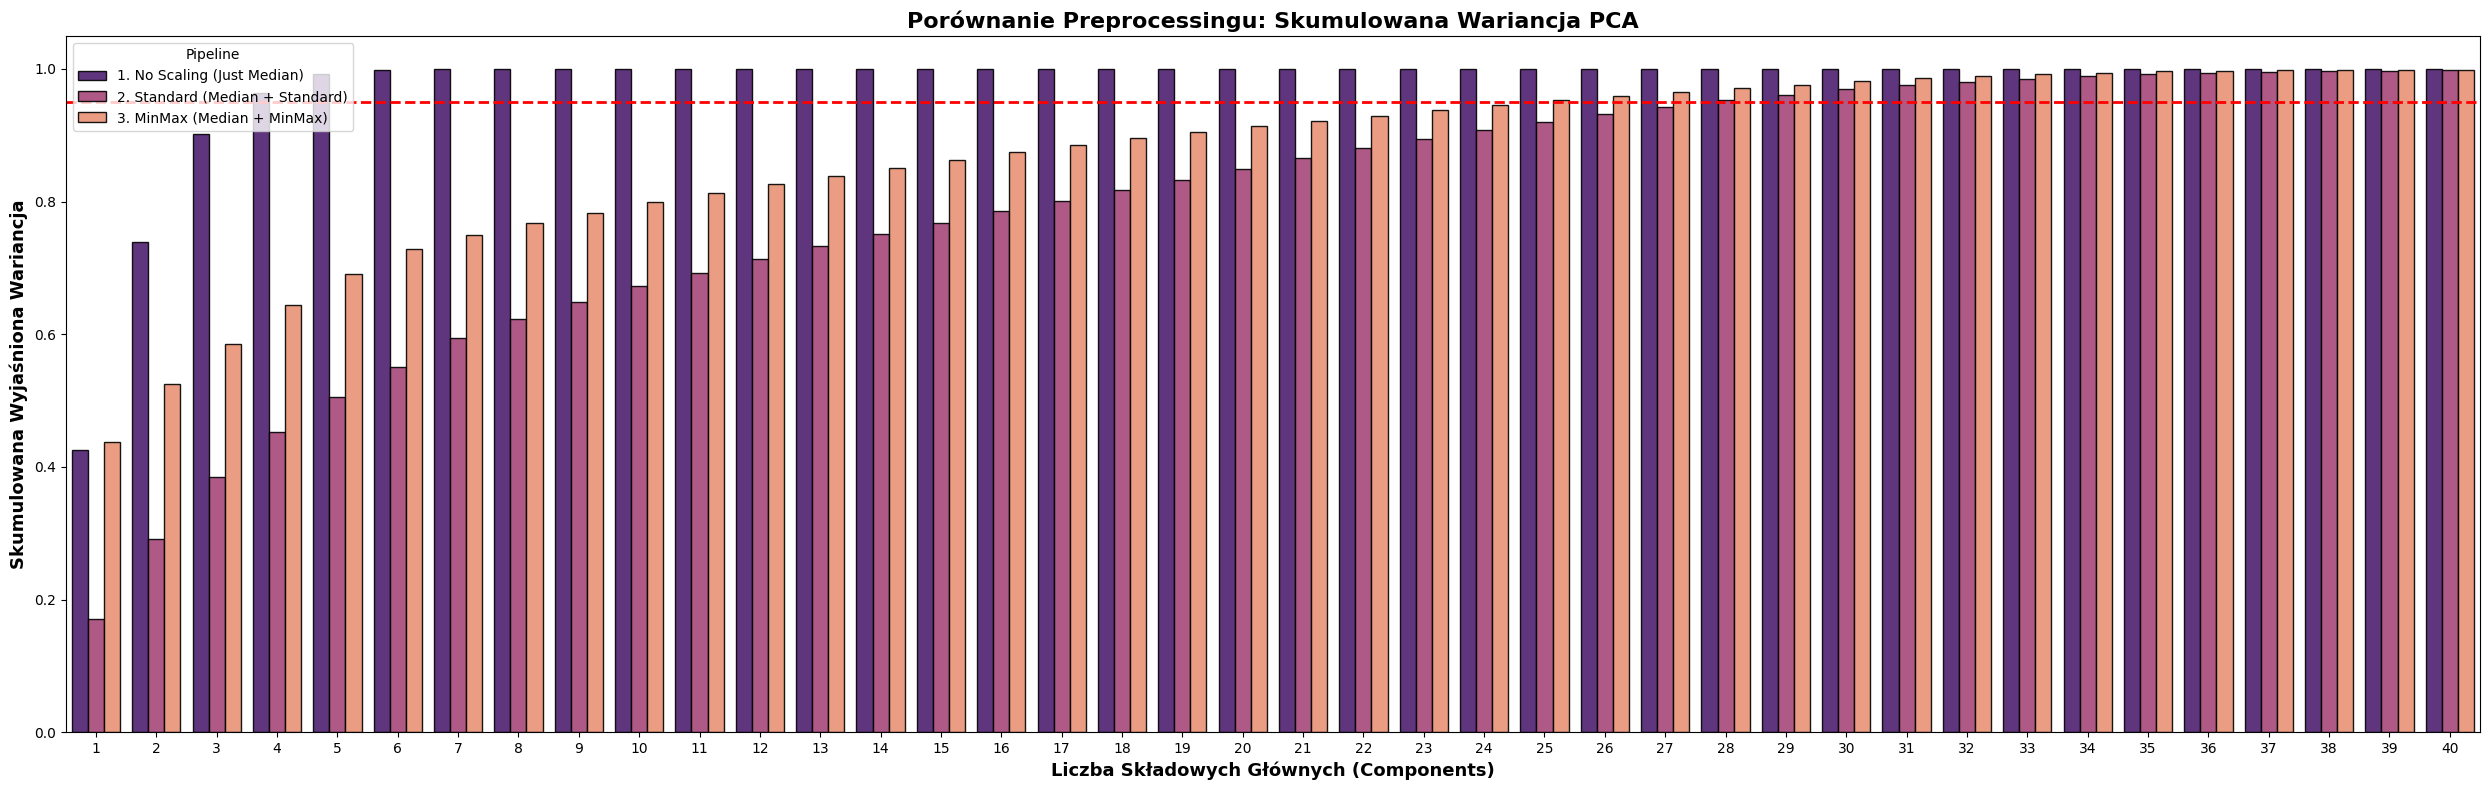

In [30]:
pipelines = {
    "1. No Scaling (Just Median)": Pipeline(
        [("imputer", SimpleImputer(strategy="median"))]
    ),
    "2. Standard (Median + Standard)": Pipeline(
        [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
    ),
    "3. MinMax (Median + MinMax)": Pipeline(
        [("imputer", SimpleImputer(strategy="median")), ("scaler", MinMaxScaler())]
    ),
}


results = []

for name, pipeline in pipelines.items():
    X_processed = pipeline.fit_transform(X_train)
    pca = PCA()
    pca.fit(X_processed)

    cumsum = np.cumsum(pca.explained_variance_ratio_)
    d = np.argmax(cumsum >= 0.95) + 1

    for comp_idx, variance in enumerate(cumsum):
        results.append(
            {
                "Pipeline": f"{name}",
                "Component": comp_idx + 1,
                "Cumulative Variance": variance,
            }
        )

df_pca = pd.DataFrame(results)
df_pca = df_pca[df_pca["Component"] <= 40]

plt.figure(figsize=(25, 8))

ax = sns.barplot(
    data=df_pca,
    x="Component",
    y="Cumulative Variance",
    hue="Pipeline",
    palette="magma",
    edgecolor="black",
    alpha=0.9,
)

plt.axhline(y=0.95, color="red", linestyle="--", linewidth=2, label="95% Threshold")
plt.xlabel("Liczba Składowych Głównych (Components)", fontsize=13, fontweight="bold")
plt.ylabel("Skumulowana Wyjaśniona Wariancja", fontsize=13, fontweight="bold")
plt.title(
    "Porównanie Preprocessingu: Skumulowana Wariancja PCA",
    fontsize=16,
    fontweight="bold",
)


plt.tight_layout()
plt.show()

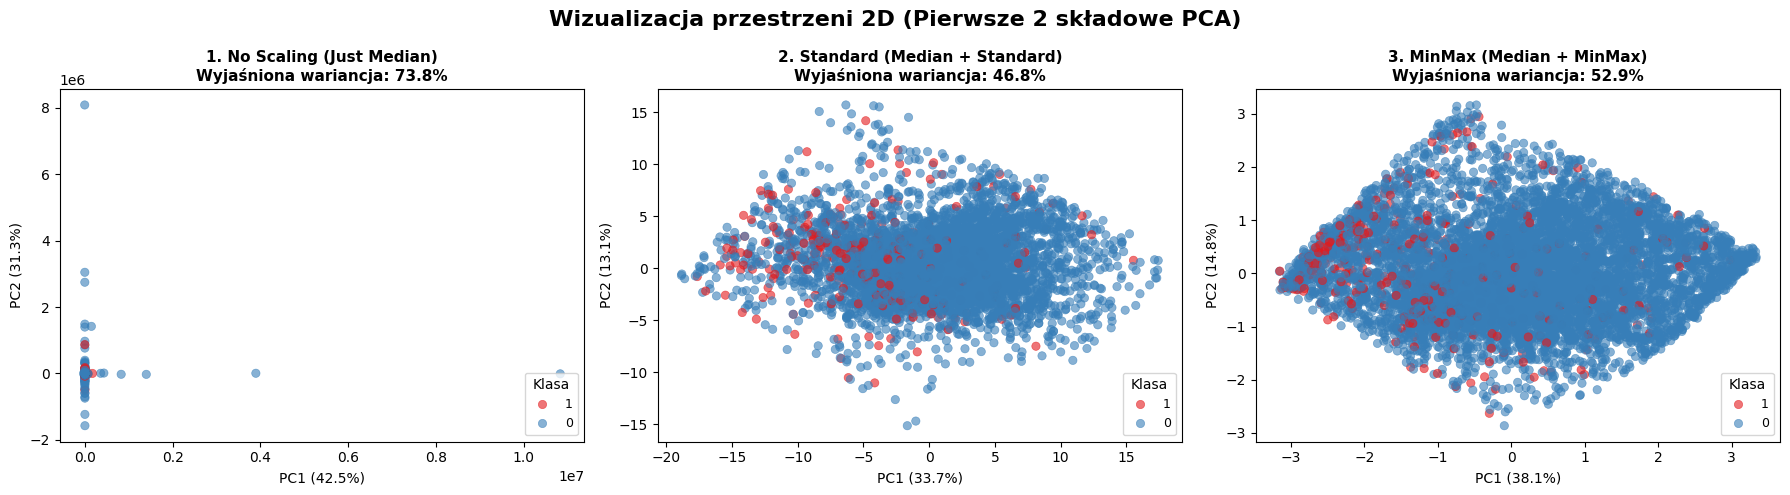

In [31]:
pipelines = {
    "1. No Scaling (Just Median)": Pipeline(
        [("imputer", SimpleImputer(strategy="median"))]
    ),
    "2. Standard (Median + Standard)": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("irq_clipping", IQRClipper(k=4)),
            ("scaler", StandardScaler()),
        ]
    ),
    "3. MinMax (Median + MinMax)": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("irq_clipping", IQRClipper(k=1)),
            ("scaler", MinMaxScaler()),
        ]
    ),
}

reversed_hue_order = np.sort(y_train.unique())[::-1]

fig, axes = plt.subplots(1, len(pipelines), figsize=(18, 5))
fig.suptitle(
    "Wizualizacja przestrzeni 2D (Pierwsze 2 składowe PCA)",
    fontsize=16,
    fontweight="bold",
)

for ax, (name, pipeline) in zip(axes, pipelines.items()):
    X_processed = pipeline.fit_transform(X_train)

    pca_2d = PCA(n_components=2)
    X_pca_2d = pca_2d.fit_transform(X_processed)

    sns.scatterplot(
        x=X_pca_2d[:, 0],
        y=X_pca_2d[:, 1],
        hue=y_train,
        hue_order=reversed_hue_order,
        palette="Set1",
        alpha=0.6,
        ax=ax,
        edgecolor=None,
    )

    var_ratio = pca_2d.explained_variance_ratio_
    total_var = (var_ratio[0] + var_ratio[1]) * 100

    ax.set_title(
        f"{name}\nWyjaśniona wariancja: {total_var:.1f}%",
        fontsize=11,
        fontweight="bold",
    )
    ax.set_xlabel(f"PC1 ({var_ratio[0] * 100:.1f}%)")
    ax.set_ylabel(f"PC2 ({var_ratio[1] * 100:.1f}%)")

    ax.legend(title="Klasa", loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

In [32]:
rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "figure.dpi": 150,
    }
)

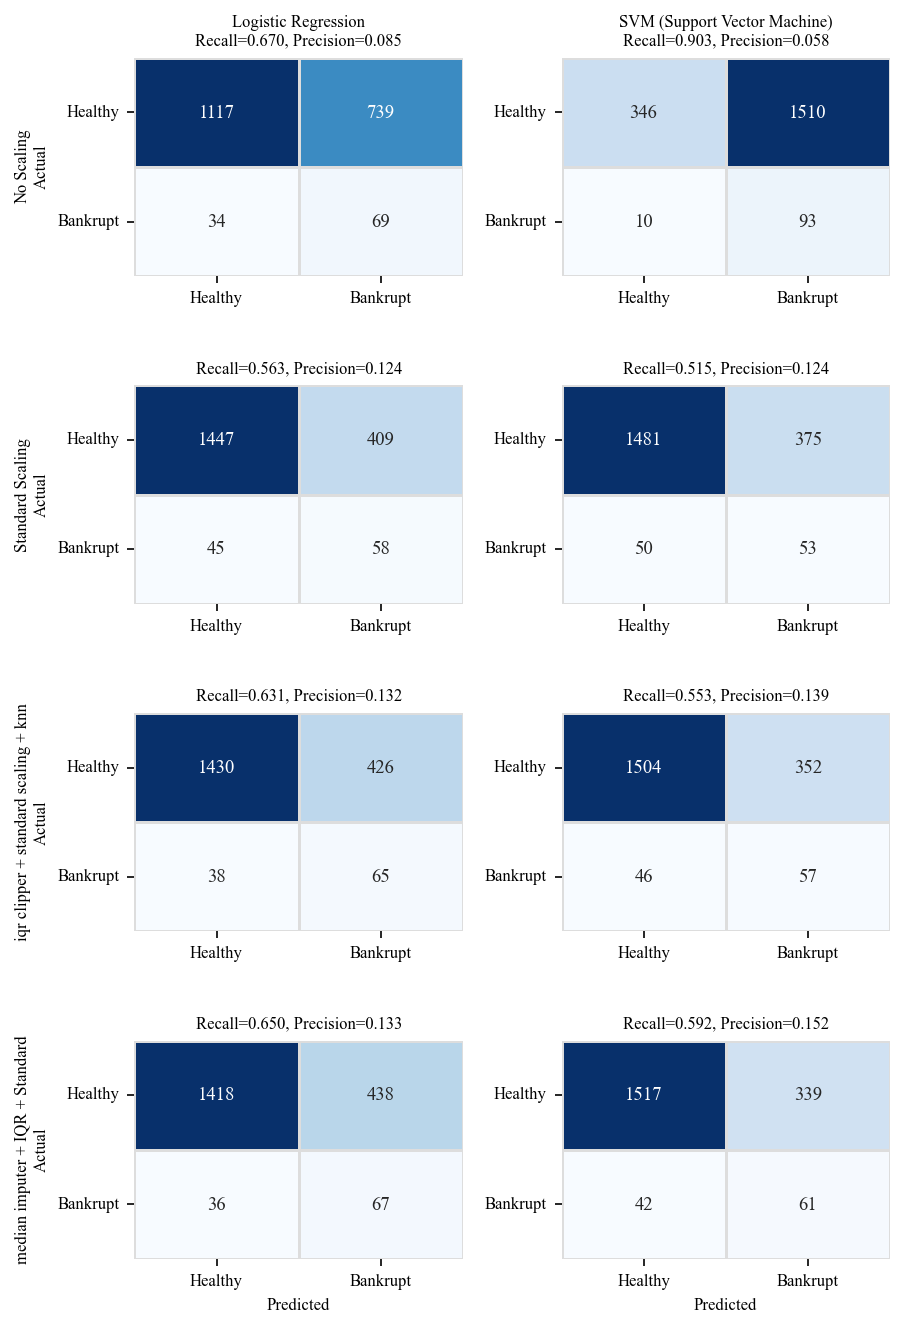

In [ ]:
from sklearn.svm import SVC


pipelines = {
    "No Scaling": Pipeline([("imputer", SimpleImputer(strategy="median"))]),
    "Standard Scaling": Pipeline(
        [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
    ),
    "iqr clipper + standard scaling + knn": Pipeline(
        [
            ("IQRClipper", IQRClipper(k=1.5)),
            ("scaler", StandardScaler()),
            ("knn", KNNImputer(n_neighbors=5)),
        ]
    ),
    "median imputer + IQR + Standard": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("clipper", IQRClipper(k=1.5)),
            ("scaler", StandardScaler()),
        ]
    ),
}

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=42
    ),
    "SVM (Support Vector Machine)": SVC(
        kernel="rbf", class_weight="balanced", random_state=42
    ),
}

n_rows, n_cols = len(pipelines), len(models)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5, 2.6 * n_rows))
fig.subplots_adjust(hspace=0.5, wspace=0.3)

for row_idx, (pipe_name, pipeline) in enumerate(pipelines.items()):
    X_tr = pipeline.fit_transform(X_train)
    X_te = pipeline.transform(X_test)

    for col_idx, (model_name, model) in enumerate(models.items()):
        ax = axes[row_idx, col_idx]

        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)

        cm = confusion_matrix(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            ax=ax,
            linewidths=0.5,
            linecolor="#dddddd",
            annot_kws={"size": 9},
        )

        if row_idx == 0:
            ax.set_title(
                f"{model_name}\nRecall={recall:.3f}, Precision={precision:.3f}",
                fontsize=8,
            )
        else:
            ax.set_title(
                f"Recall={recall:.3f}, Precision={precision:.3f}",
                fontsize=8,
            )

        ax.set_xticklabels(["Healthy", "Bankrupt"], fontsize=8)
        ax.set_yticklabels(["Healthy", "Bankrupt"], fontsize=8, rotation=0)

        ax.set_xlabel("Predicted" if row_idx == n_rows - 1 else "", fontsize=8)
        ax.set_ylabel(f"{pipe_name}\nActual" if col_idx == 0 else "", fontsize=8)

plt.show()

Liczba wierszy przed filtracją: 7833
Liczba wierszy po filtracji: 7784
Odrzucono: 49 wierszy



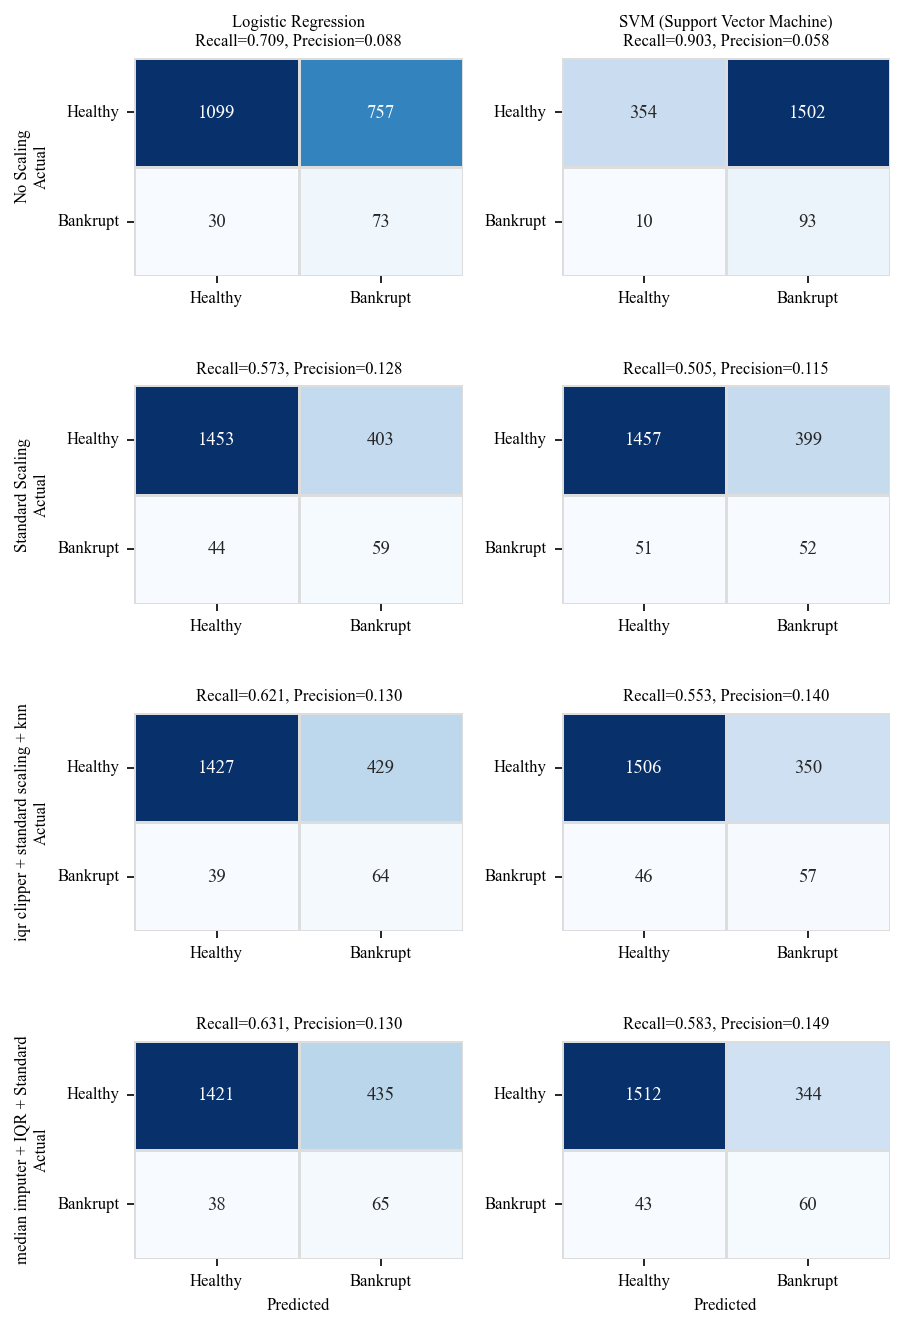

In [39]:
mask = X_train.isna().sum(axis=1) <= 8
X_train_filtered = X_train[mask].copy()
y_train_filtered = y_train[mask].copy()

print(f"Liczba wierszy przed filtracją: {len(X_train)}")
print(f"Liczba wierszy po filtracji: {len(X_train_filtered)}")
print(f"Odrzucono: {len(X_train) - len(X_train_filtered)} wierszy\n")

n_rows, n_cols = len(pipelines), len(models)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5, 2.6 * n_rows))
fig.subplots_adjust(hspace=0.5, wspace=0.3)

for row_idx, (pipe_name, pipeline) in enumerate(pipelines.items()):
    X_tr = pipeline.fit_transform(X_train_filtered)
    X_te = pipeline.transform(X_test)

    for col_idx, (model_name, model) in enumerate(models.items()):
        ax = axes[row_idx, col_idx]

        model.fit(X_tr, y_train_filtered)
        y_pred = model.predict(X_te)

        cm = confusion_matrix(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            ax=ax,
            linewidths=0.5,
            linecolor="#dddddd",
            annot_kws={"size": 9},
        )

        if row_idx == 0:
            ax.set_title(
                f"{model_name}\nRecall={recall:.3f}, Precision={precision:.3f}",
                fontsize=8,
            )
        else:
            ax.set_title(
                f"Recall={recall:.3f}, Precision={precision:.3f}",
                fontsize=8,
            )

        ax.set_xticklabels(["Healthy", "Bankrupt"], fontsize=8)
        ax.set_yticklabels(["Healthy", "Bankrupt"], fontsize=8, rotation=0)

        ax.set_xlabel("Predicted" if row_idx == n_rows - 1 else "", fontsize=8)
        ax.set_ylabel(f"{pipe_name}\nActual" if col_idx == 0 else "", fontsize=8)

plt.show()